In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split #, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    # precision_recall_curve, average_precision_score, roc_curve
)

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 15
np.random.seed(RANDOM_STATE)


In [ ]:
data_path = "data/cancer_data.csv"
df_raw = pd.read_csv(data_path)

print(f"dataset shape: {df_raw.shape}")
df_raw.head()

dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
print("dataset info:")
print(df_raw.info())

dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se

In [ ]:
df_clean = df_raw.copy()

# Remove id column and unamed:32 columns
cols_to_drop = ['id','Unnamed: 32']
df_clean = df_clean.drop(cols_to_drop, axis=1)
print(f"\Columns after cleaning [{len(df_clean.columns)}]: {list(df_clean.columns)}")

\Columns after cleaning [31]: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [ ]:
# Separate feature variables and target (diagnosis of M/B)

y_labels = df_clean['diagnosis']  # Original labels (M/B)
y = y_labels.map({'M': 1, 'B': 0})  # Binary encode the diagnosis, 1 = malignant, 0 = benign
X = df_clean.drop(['diagnosis'], axis=1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nTarget variable distribution (in %):")
print(y.value_counts(normalize=True) * 100)

Features shape: (569, 30)
Target shape: (569,)

Target distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64

Target variable distribution (in %):
diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64


In [ ]:
# Group features by type (mean, se, worst)
mean_features = [col for col in X.columns if '_mean' in col]
se_features = [col for col in X.columns if '_se' in col]
worst_features = [col for col in X.columns if '_worst' in col]

print(f"Mean features ({len(mean_features)}): {mean_features}")
print(f"\nStandard Error features ({len(se_features)}): {se_features}")
print(f"\nWorst features ({len(worst_features)}): {worst_features}")

Mean features (10): ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

Standard Error features (10): ['radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se']

Worst features (10): ['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


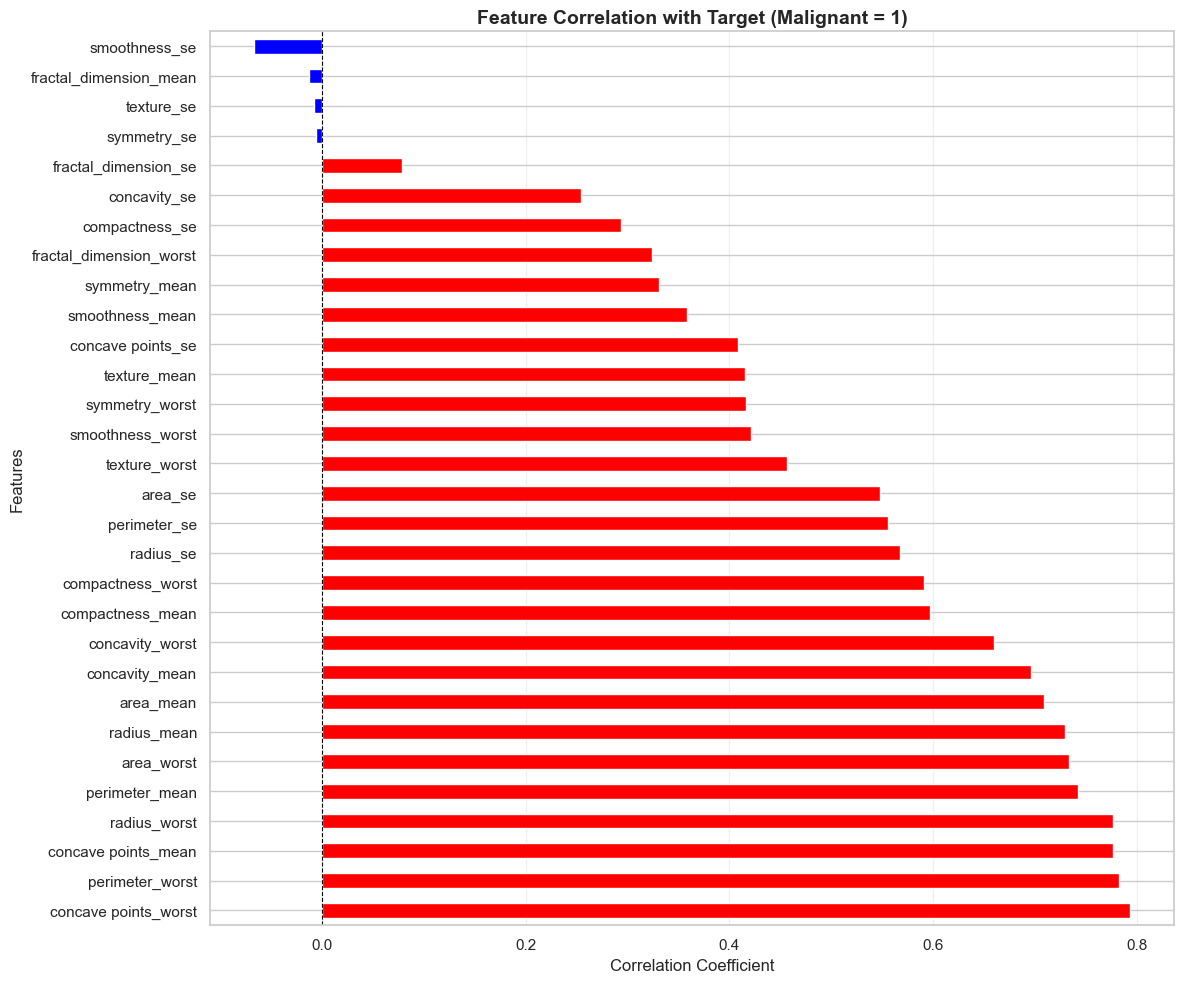


Top 10 features most correlated with malignancy:
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
dtype: float64


In [ ]:
# Correlation with target variable
target_corr = X.corrwith(y).sort_values(ascending=False)

plt.figure(figsize=(12, 10))
target_corr.plot(kind='barh', color=['red' if x > 0 else 'blue' for x in target_corr])
plt.title('Feature Correlation with Target (Malignant = 1)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 features most correlated with malignancy:")
print(target_corr.head(10))

# Modelling with Logistic Regression

Logistic Regression is a statistical model that estimates the probability of a binary outcome (malignant vs. benign) by modeling the relationship between input features and the log-odds of the outcome. It uses the **logistic (sigmoid) function** to map a linear combination of features to probabilities between 0 and 1. The model learns weights (coefficients) for each feature that maximize the likelihood of correctly predicting the training data outcomes. 

We chose to use Logisitc Regression as it can produce and intepretable model with known coefficients for each of the featuers, that indicate to us how much each feature influences the risk of Malignancy in cancers. This can be used to better understand diseases and the symptoms that are the strongest indicators and best predictors for future diagnosis. The model also outputs a probability to give us a prediction confidence, which doctors can make use of to decide if further screening or tests are needed (e.g. if confidence is below 90%, doctors can perform more tests or spend more time analyzing the scans, vs a 99.8% case which is more clear cut and almost definitely malignant)

## Train-Test Split

Before training the models, we first split the dataset into training (80%) and testing (20%) sets. The trainig set is used to train the model on predictive patterns in breast cancer features, and the test set will be used to evaluate its predictive performance. We use **stratified sampling** (`stratify=y`) so that both have the same proportion of benight and malignant cases as the original dataset. This separation of data ensures that our tests of model performance are fair and unbiased, and not based on a model that is overfitted to that specific set of data.

In [ ]:
# Split the data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 455 samples
Test set size: 114 samples

Training set class distribution:
diagnosis
0    285
1    170
Name: count, dtype: int64

Test set class distribution:
diagnosis
0    72
1    42
Name: count, dtype: int64


## Feature Standardization

Logistic Regression makes use of gradient descent optimization and calculates distances in feature space. It is hence sensitive to the scale of our input features, meaning that without standardizing, features (such as 'area_mea' with larger absolute values) would have a much larger weightage/importance during the model's learning process and cause bias towards them. We hence use the StandardScaler to transform each feature such that they have a mean of 0 and standard deviation of 1. The scaling allows all features to contribute equally to the model, letting it learn the relationships features and malignancy risks is an unbiased manner.

We scale the training data in isolation, separately from the testing dataset, to ensure that there is no data-leakage, and properly simulate the use of the model in a real-world environment, where the distributions and means of future data are unknown.

In [ ]:
# Standardize features (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier interpretation
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Feature scaling completed.")
print(f"\nScaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")
print(f"\nSample statistics after scaling (first 5 features):")
print(X_train_scaled_df.iloc[:, :5].describe())

Feature scaling completed.

Scaled training data shape: (455, 30)
Scaled test data shape: (114, 30)

Sample statistics after scaling (first 5 features):
        radius_mean  texture_mean  perimeter_mean     area_mean  \
count  4.550000e+02  4.550000e+02    4.550000e+02  4.550000e+02   
mean   6.246530e-17  4.411611e-16    1.366428e-16  1.620194e-16   
std    1.001101e+00  1.001101e+00    1.001101e+00  1.001101e+00   
min   -2.061260e+00 -2.211853e+00   -2.016336e+00 -1.466657e+00   
25%   -6.824742e-01 -7.433369e-01   -6.831502e-01 -6.503169e-01   
50%   -2.150891e-01 -9.220221e-02   -2.235392e-01 -2.954488e-01   
75%    4.730057e-01  5.924128e-01    4.925745e-01  3.674506e-01   
max    4.034653e+00  4.615825e+00    4.043828e+00  5.307445e+00   

       smoothness_mean  
count     4.550000e+02  
mean      8.237611e-16  
std       1.001101e+00  
min      -3.136898e+00  
25%      -7.230375e-01  
50%      -6.735392e-02  
75%       6.569857e-01  
max       4.910756e+00  


### Training the logistic regression model


In [ ]:
# Train Logistic Regression model
print("Training Logistic Regression model...\n")

lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=10000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Probability predictions (for risk assessment)
y_train_proba_lr = lr_model.predict_proba(X_train_scaled)[:, 1]
y_test_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained successfully.")

Training Logistic Regression model...

Logistic Regression model trained successfully.


## Model Evaluation Metrics

The `evaluate_model()` function below computes five key metrics: 
1. **Accuracy** measures the proportion of correct predictions (both B and M) out of all predictions. While intuitive, it can be misleading in certain cases where there is a much larger proportion of one class, and the model can achieve high accuracy by simply predicting the majority class.
2. **Precision** calculates what percentage of predicted malignant cases are actually malignant (TP / (TP + FP)). High precision means fewer false positives, and is important in a medical context as it reduces unnecessary patient anxiety and invasive follow-up procedures.
3. **Recall** (sensitivity or True Positive rate) measures what percentage of actual malignant cases the model successfully identifies (TP / (TP + FN)). This could be seen as the most critical metric in the context of cancer screening, as false negatives mean that the model has let a cancer diagnosis go unnoticed, and this could be life-threatening; 
4. **F1-Score** provides the harmonic mean of precision and recall (2 × precision × recall / (precision + recall)), a single metric that balances both concerns. This is useful when trying to optimize for both avoiding false positives and catching true positives; 
5. **ROC-AUC** (Area Under Receiver Operating Characteristic Curve) This metric eevaluates the model's ability to discriminate between classes across all possible probability thresholds, with 1.0 representing perfect classification and 0.5 representing random guessing. This metric is threshold-independent and useful for our risk assessment application.

We also generate a detailed classification report showing per-class precision, recall, and F1-scores for both benign and malignant cases. We evaluate on both the training and test sets to check for overfitting (where training performance significantly exceeds test performance, indicating the model has memorized training data rather than learned generalizable patterns)

In [ ]:
# MOdel evaluation of trained Logistic Regression model:
def evaluate_model(y_true, y_pred, y_proba, model_name):
  
    print(f"{'='*33}")
    print(f"{model_name} - Performance Metrics")
    print(f"{'='*33}\n")
    
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
   
    print("Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=['Benign', 'Malignant']))
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }

# Evaluate on both training and test sets
print("LOGISTIC REGRESSION - TRAINING SET")
lr_train_metrics = evaluate_model(y_train, y_train_pred_lr, y_train_proba_lr, "Logistic Regression")

print("LOGISTIC REGRESSION - TEST SET")
lr_test_metrics = evaluate_model(y_test, y_test_pred_lr, y_test_proba_lr, "Logistic Regression")

LOGISTIC REGRESSION - TRAINING SET
Logistic Regression - Performance Metrics

Accuracy:  0.9912
Precision: 1.0000
Recall:    0.9765
F1-Score:  0.9881
ROC-AUC:   0.9975
Classification Report:

              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99       285
   Malignant       1.00      0.98      0.99       170

    accuracy                           0.99       455
   macro avg       0.99      0.99      0.99       455
weighted avg       0.99      0.99      0.99       455

LOGISTIC REGRESSION - TEST SET
Logistic Regression - Performance Metrics

Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9286
F1-Score:  0.9630
ROC-AUC:   0.9977
Classification Report:

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.

### Feature Importance and Coefficient Analysis

Logistic Regression coefficients represent how each feature influences the log-odds of malignancy. A **positive coefficient** indicates that higher values of that feature increase the probability of malignancy, while **negative coefficients** suggests lower probability. The magnitude of the coefficient reflects the strength of this relationship, and the coefficients apply to the standardized features. 

By diving into and analyzing the coefficients of the trained model, we can identify which tissue characteristics are most predictive of breast cancer and better understand the biological patterns that the model has learned. This interpretability is a key advantage of using a Logistic Regression over more black-boxed models like Random Forest, especially in medical contexts where clinicians need to understand the models reasoning and decisions to better trust its output.

LOGISTIC REGRESSION - FEATURE COEFFICIENTS ANALYSIS
Top 15 most important features:

             Feature  Coefficient  Abs_Coefficient
           radius_se     1.297983         1.297983
       texture_worst     1.151662         1.151662
 concave points_mean     1.135200         1.135200
      compactness_se    -0.978123         0.978123
      concavity_mean     0.916969         0.916969
        radius_worst     0.902565         0.902565
             area_se     0.888417         0.888417
     concavity_worst     0.882568         0.882568
          area_worst     0.856220         0.856220
        perimeter_se     0.848495         0.848495
    smoothness_worst     0.796193         0.796193
     perimeter_worst     0.765109         0.765109
fractal_dimension_se    -0.737563         0.737563
concave points_worst     0.729621         0.729621
      symmetry_worst     0.710054         0.710054
Coefficient Interpretation:
  • Positive coefficient: Higher feature value → Higher malignancy prob

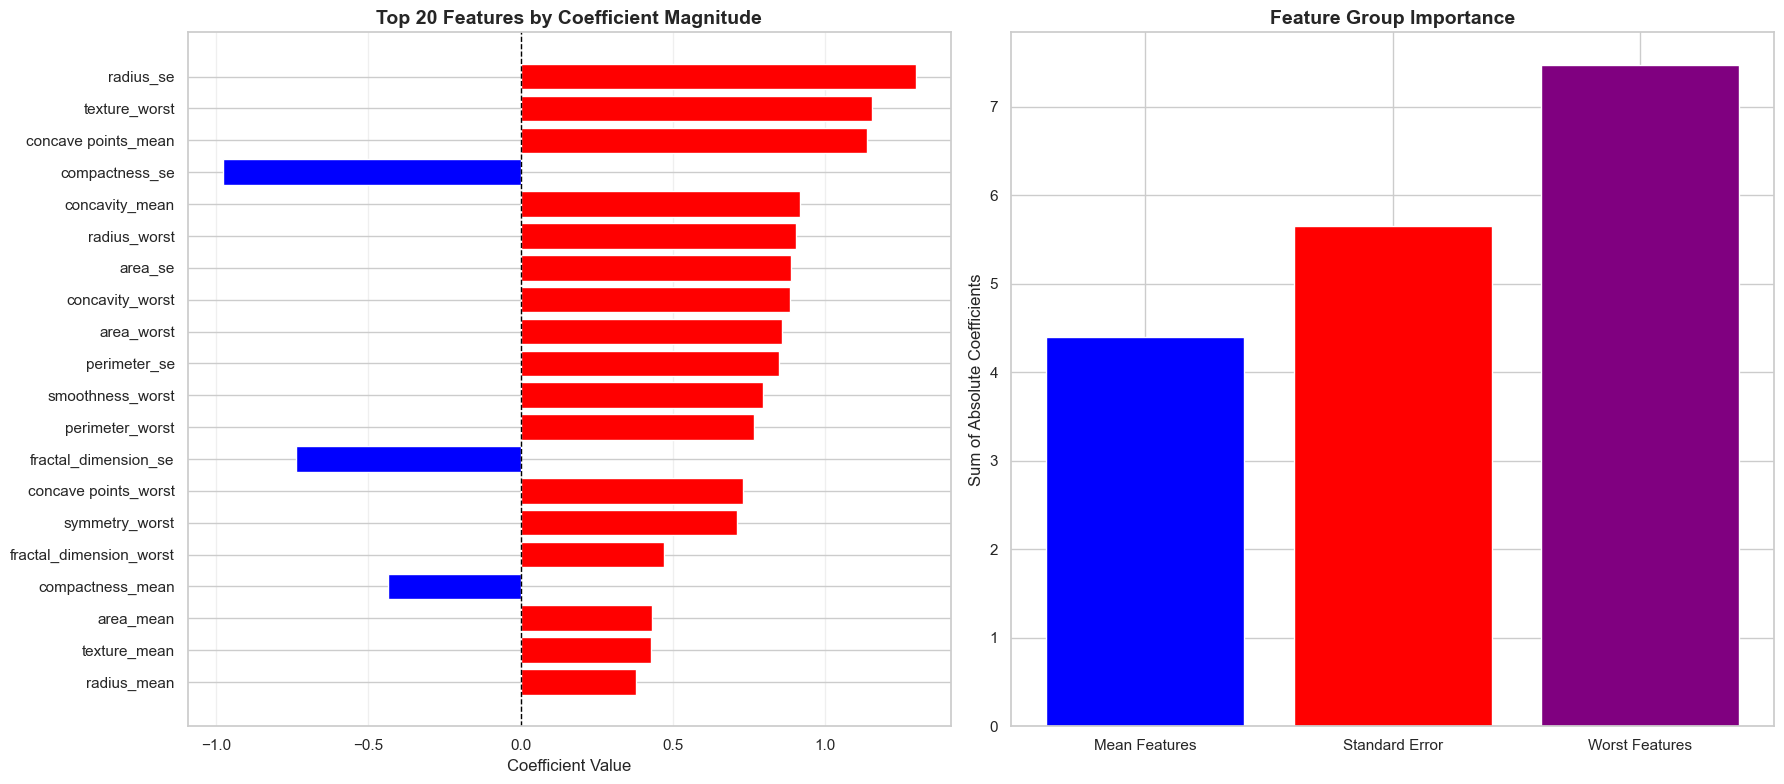

In [ ]:
# Extract and analyze Logistic Regression coefficients
lr_coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("LOGISTIC REGRESSION - FEATURE COEFFICIENTS ANALYSIS")

print("Top 15 most important features:\n")
print(lr_coefficients.head(15).to_string(index=False))

print("Coefficient Interpretation:")
print("  • Positive coefficient: Higher feature value → Higher malignancy probability")
print("  • Negative coefficient: Higher feature value → Lower malignancy probability")
print("  • Larger |coefficient|: Stronger influence on prediction\n")

# Identifying strongest predictors of malignancy
strongest_positive = lr_coefficients[lr_coefficients['Coefficient'] > 0].head(5)
strongest_negative = lr_coefficients[lr_coefficients['Coefficient'] < 0].head(5)

print("\nStrongest Positive Predictors of Malignancy:")
for _, row in strongest_positive.iterrows():
    print(f"  • {row['Feature']}: {row['Coefficient']:.4f}")
    print(f"    → Each 1-std increase in {row['Feature']} multiplies odds of malignancy by {np.exp(row['Coefficient']):.3f}x")

print("\nStrongest Negative Predictors (Protective Features):")
for _, row in strongest_negative.iterrows():
    print(f"  • {row['Feature']}: {row['Coefficient']:.4f}")
    print(f"    → Each 1-std increase in {row['Feature']} multiplies odds of malignancy by {np.exp(row['Coefficient']):.3f}x")

# Visualize coefficients
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# All coefficients
top_20 = lr_coefficients.head(20)
colors = ['red' if x > 0 else 'blue' for x in top_20['Coefficient']]
axes[0].barh(range(len(top_20)), top_20['Coefficient'], color=colors)
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels(top_20['Feature'])
axes[0].set_xlabel('Coefficient Value', fontsize=12)
axes[0].set_title('Top 20 Features by Coefficient Magnitude', fontsize=14, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Group by feature type
mean_coefs = lr_coefficients[lr_coefficients['Feature'].str.contains('_mean')]['Abs_Coefficient'].sum()
se_coefs = lr_coefficients[lr_coefficients['Feature'].str.contains('_se')]['Abs_Coefficient'].sum()
worst_coefs = lr_coefficients[lr_coefficients['Feature'].str.contains('_worst')]['Abs_Coefficient'].sum()

feature_groups = ['Mean Features', 'Standard Error', 'Worst Features']
group_importances = [mean_coefs, se_coefs, worst_coefs]
axes[1].bar(feature_groups, group_importances, color=['blue', 'red', 'purple'])
axes[1].set_ylabel('Sum of Absolute Coefficients', fontsize=12)
axes[1].set_title('Feature Group Importance', fontsize=14, fontweight='bold')
# axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

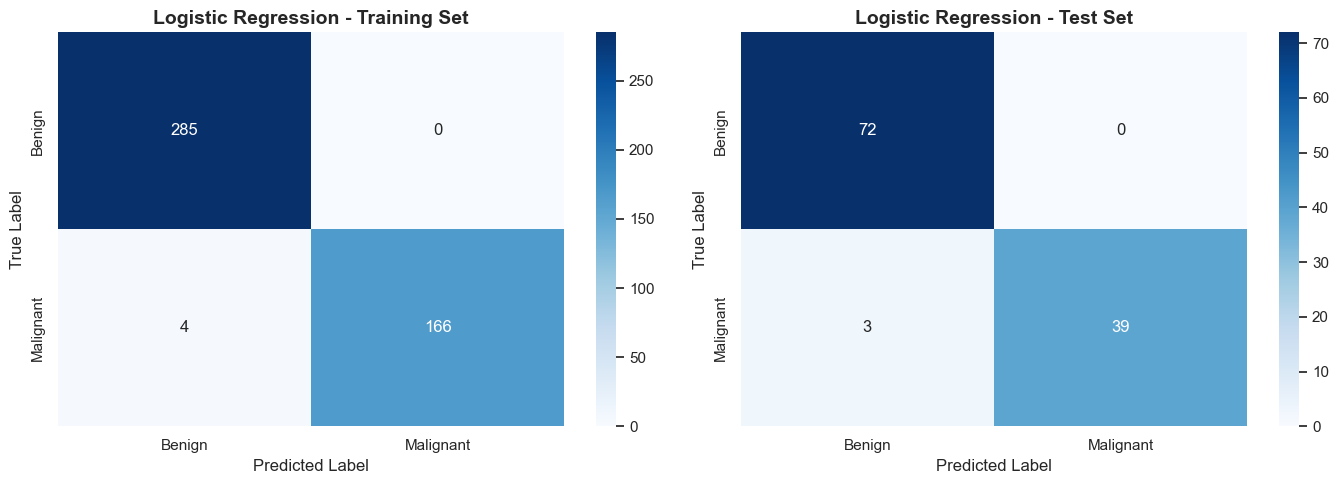

In [ ]:
# Performance Matrix for Logistic Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
cm_train = confusion_matrix(y_train, y_train_pred_lr)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[0].set_title('Logistic Regression - Training Set', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Test set
cm_test = confusion_matrix(y_test, y_test_pred_lr)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[1].set_title('Logistic Regression - Test Set', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

## Random Forest Classifier

The Random Forest Classifier is a type of ensemble learning method that constructs multiple decision trees (each built with a random subset of data and features for robustness) during training and outputs the class that is the mode of the individual trees' predictions (for classification) or mean prediction (for regression). 
Unline Logistic Regression which captures linear relations, Random Forest is able to capture complex, non-linear interactions and hierarchical relationships between features. 
The algorithm works by creating `n_estimators` different decision trees, each trained on a random subset of the data (bootstrap sampling) and considering only a random subset of features at each split. The randomness reduces overfitting and increases model robustness.

Random Forest DOES NOT require standardization because decision trees make splits based on feature value thresholds rather than distances or magnitudes. Random Forest also provides built-in feature importance scores based on how much each feature reduces impurity (Gini or entropy) across all trees, offering some interpretability. In medical diagnosis, Random Forest may be able to achieve a higher accuracy than linear models when relationships between tissue characteristics and cancer status are non-linear or involve feature interactions.

In [ ]:

# Train Random Forest model (on non-scaled data as RF doesn't require scaling)
print("Training Random Forest model...\n")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Probability predictions
y_train_proba_rf = rf_model.predict_proba(X_train)[:, 1]
y_test_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully.")

Training Random Forest model...

Random Forest model trained successfully.


Here we evaluate the Random Forest classifier with similar metrics to the ones used for LR

In [ ]:
# Evaluate Random Forest (reusing the function defined above)
print("RANDOM FOREST - TRAINING SET")
rf_train_metrics = evaluate_model(y_train, y_train_pred_rf, y_train_proba_rf, "Random Forest")

print("RANDOM FOREST - TEST SET")
rf_test_metrics = evaluate_model(y_test, y_test_pred_rf, y_test_proba_rf, "Random Forest")

RANDOM FOREST - TRAINING SET
Random Forest - Performance Metrics

Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000
Classification Report:

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       285
   Malignant       1.00      1.00      1.00       170

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455

RANDOM FOREST - TEST SET
Random Forest - Performance Metrics

Accuracy:  0.9912
Precision: 1.0000
Recall:    0.9762
F1-Score:  0.9880
ROC-AUC:   0.9972
Classification Report:

              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99        72
   Malignant       1.00      0.98      0.99        42

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99  

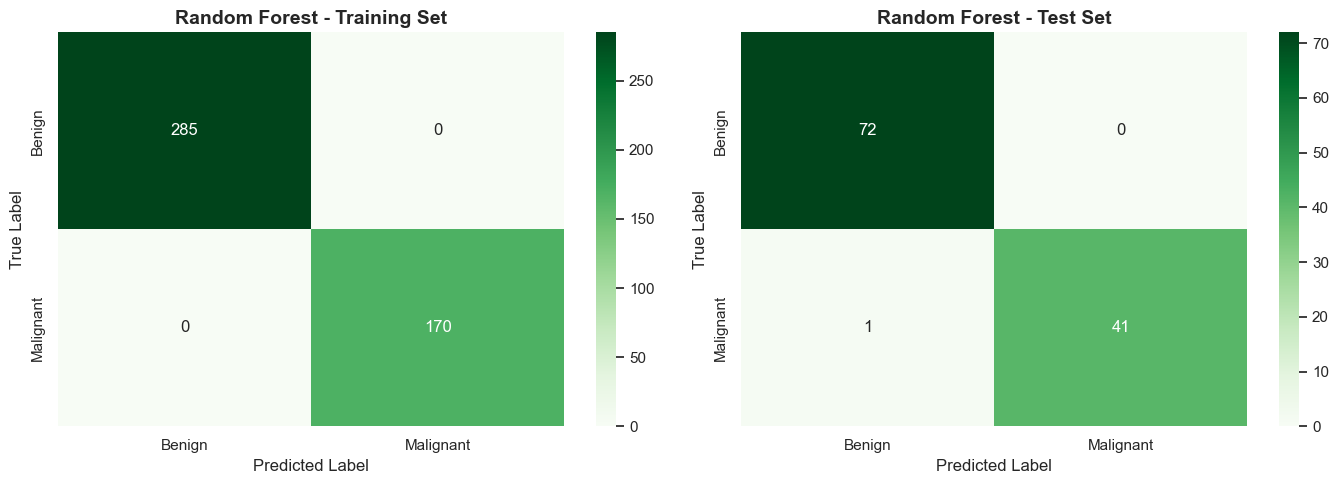

In [ ]:
# Confusion Matrix for Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
cm_train_rf = confusion_matrix(y_train, y_train_pred_rf)
sns.heatmap(cm_train_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[0].set_title('Random Forest - Training Set', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Test set
cm_test_rf = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm_test_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[1].set_title('Random Forest - Test Set', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

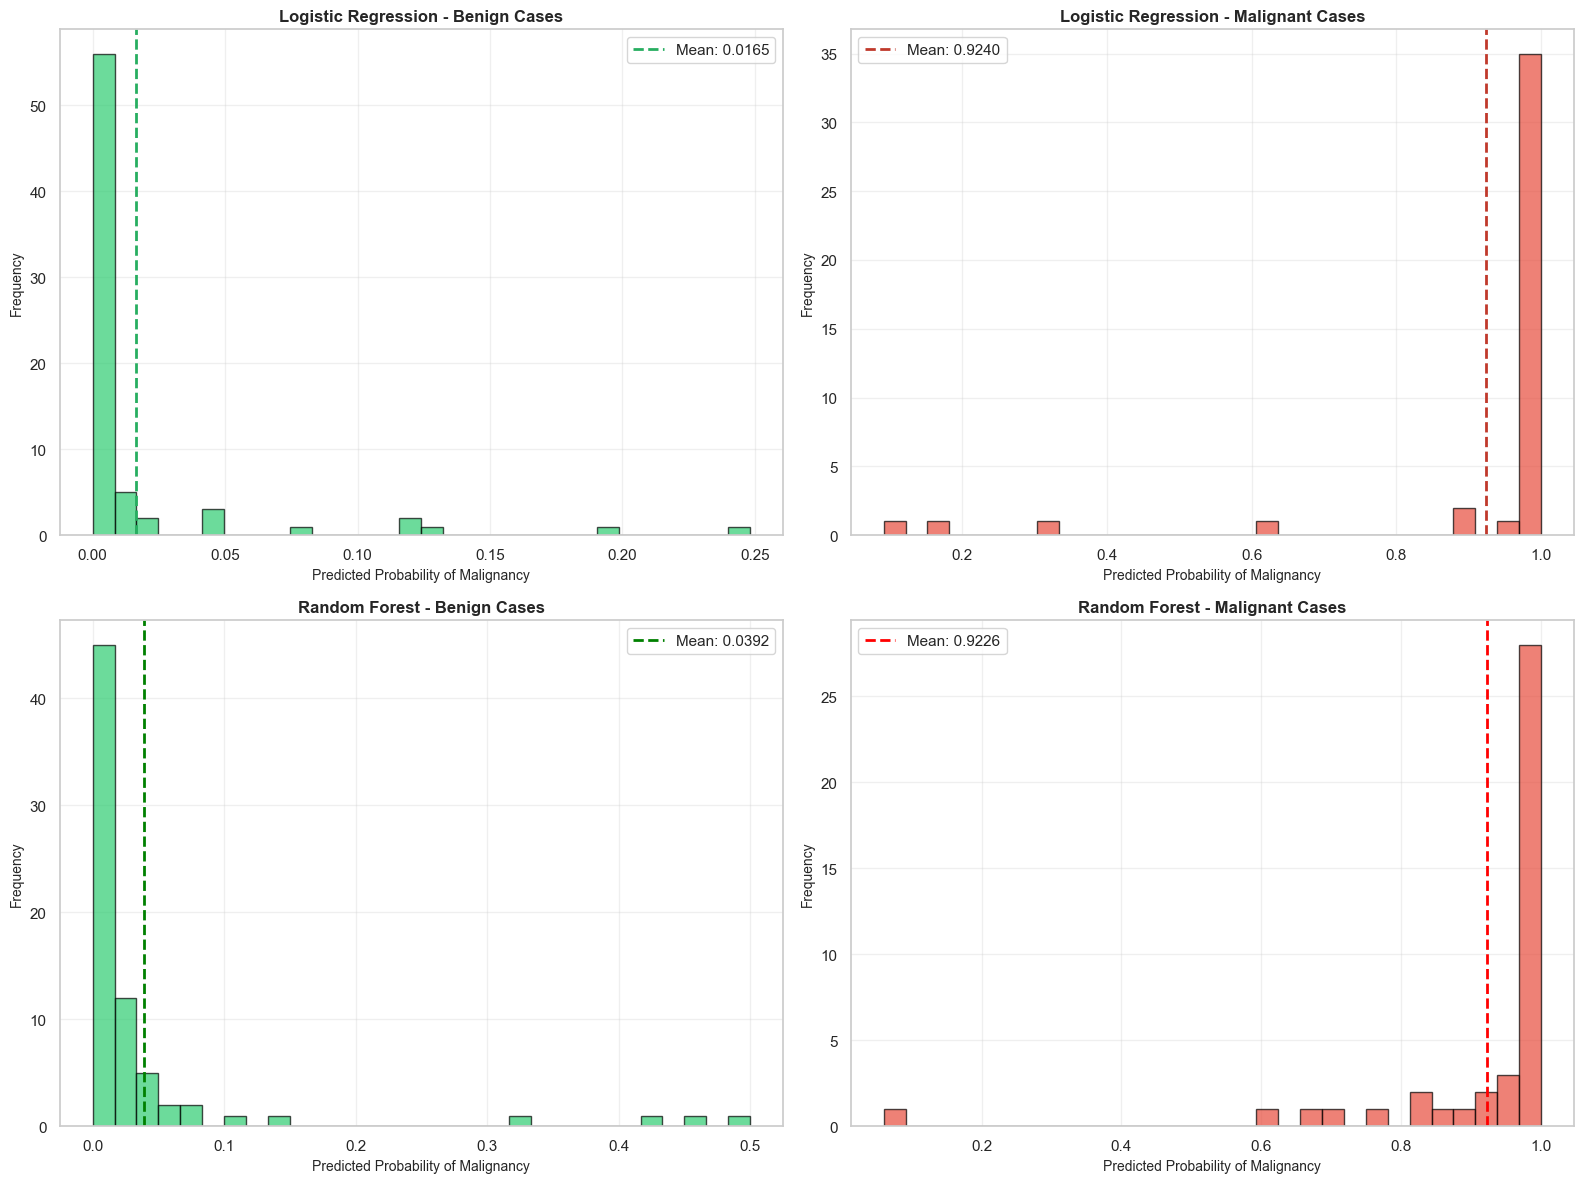

In [ ]:
# Analyze probability distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Logistic Regression - Benign cases
benign_proba_lr = y_test_proba_lr[y_test == 0]
axes[0, 0].hist(benign_proba_lr, bins=30, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(benign_proba_lr.mean(), color='#27ae60', linestyle='--', linewidth=2, 
                   label=f'Mean: {benign_proba_lr.mean():.4f}')
axes[0, 0].set_title('Logistic Regression - Benign Cases', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Predicted Probability of Malignancy', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Logistic Regression - Malignant cases
malignant_proba_lr = y_test_proba_lr[y_test == 1]
axes[0, 1].hist(malignant_proba_lr, bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(malignant_proba_lr.mean(), color='#c0392b', linestyle='--', linewidth=2,
                   label=f'Mean: {malignant_proba_lr.mean():.4f}')
axes[0, 1].set_title('Logistic Regression - Malignant Cases', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Predicted Probability of Malignancy', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Random Forest - Benign cases
benign_proba_rf = y_test_proba_rf[y_test == 0]
axes[1, 0].hist(benign_proba_rf, bins=30, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(benign_proba_rf.mean(), color='green', linestyle='--', linewidth=2,
                   label=f'Mean: {benign_proba_rf.mean():.4f}')
axes[1, 0].set_title('Random Forest - Benign Cases', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Predicted Probability of Malignancy', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Random Forest - Malignant cases
malignant_proba_rf = y_test_proba_rf[y_test == 1]
axes[1, 1].hist(malignant_proba_rf, bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(malignant_proba_rf.mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {malignant_proba_rf.mean():.4f}')
axes[1, 1].set_title('Random Forest - Malignant Cases', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Predicted Probability of Malignancy', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Breast cancer Risk Assessment function based on Logisitic Regression/Random Forest models

Here we design the final function that will take a patients measured features, and based on the logisitc regression and random forest models trained on the training data sets, output a probability of them having benign or malignant cancers. This function can be used on unseen data that is outside of our dataset, as long as we have the same features available.

The cell below does a trial run of the function on randomly selected patients from our current dataset, running the functon to output a probability of being malignant, and comparing it to the actual diagnosis which we possess in this case.

In [ ]:
# Create risk assessment function
def assess_cancer_risk(patient_features, model, scaler=None, model_name="Model", true_label=None):
    """
    Assess cancer risk for a patient
    
    Parameters:
    - patient_features: Features for a single patient (DataFrame or array)
    - model: Trained model
    - scaler: StandardScaler object (required for Logistic Regression)
    - model_name: Name of the model for display
    - true_label: Actual diagnosis (0=Benign, 1=Malignant) - optional
    
    Returns:
    - Dictionary with risk assessment results
    """
    # Scale features if scaler is provided
    if scaler is not None:
        features_processed = scaler.transform(patient_features)
    else:
        features_processed = patient_features
    
    # Get prediction and probability
    prediction = model.predict(features_processed)[0]
    probability = model.predict_proba(features_processed)[0]
    
    # Determine risk level
    risk_score = probability[1] * 100  # Probability of malignancy
    
    if risk_score < 30:
        risk_level = "Low Risk"
        risk_color = "green"
    elif risk_score < 70:
        risk_level = "Moderate Risk"
        risk_color = "orange"
    else:
        risk_level = "High Risk"
        risk_color = "red"
    
    # Check if prediction matches actual diagnosis
    prediction_correct = None
    if true_label is not None:
        prediction_correct = (prediction == true_label)
    
    return {
        'model': model_name,
        'prediction': 'Malignant' if prediction == 1 else 'Benign',
        'risk_score': risk_score,
        'benign_probability': probability[0] * 100,
        'malignant_probability': probability[1] * 100,
        'risk_level': risk_level,
        'risk_color': risk_color,
        'prediction_correct': prediction_correct
    }

# Test on random samples from test set
print("\n" + "="*100)
print("CANCER RISK ASSESSMENT - SAMPLE PREDICTIONS")
print("="*100 + "\n")

sample_indices = np.random.choice(X_test.index, size=5, replace=False)

for idx in sample_indices:
    patient_features = X_test.loc[[idx]]
    true_diagnosis_binary = y_test.loc[idx]  # 0 or 1
    true_label = 'Malignant' if true_diagnosis_binary == 1 else 'Benign'
    
    print(f"\nPatient ID: {idx}")
    print(f"ACTUAL DIAGNOSIS: {true_label}")
    
    # risk assessment for Logisitc Regression
    lr_assessment = assess_cancer_risk(patient_features, lr_model, scaler, 
                                       "Logistic Regression", true_diagnosis_binary)
    print(f"\n{lr_assessment['model']}:")
    print(f"  Predicted Diagnosis: {lr_assessment['prediction']}")
    
    if lr_assessment['prediction_correct']:
        print(f" ✓ CORRECT PREDICTION")
    else:
        print(f" ✗ INCORRECT PREDICTION")
    
    print(f"  Risk Level: {lr_assessment['risk_level']}")
    print(f"  Malignancy Risk Score: {lr_assessment['risk_score']:.2f}%")
    print(f"  Benign Probability: {lr_assessment['benign_probability']:.2f}%")
    print(f"  Malignant Probability: {lr_assessment['malignant_probability']:.2f}%")
    
    # Risk assessment for Random Forest
    rf_assessment = assess_cancer_risk(patient_features, rf_model, None, 
                                       "Random Forest", true_diagnosis_binary)
    print(f"\n{rf_assessment['model']}:")
    print(f"  Predicted Diagnosis: {rf_assessment['prediction']}")
    
    # Show if prediction is correct
    if rf_assessment['prediction_correct']:
        print(f" ✓ CORRECT PREDICTION")
    else:
        print(f" ✗ INCORRECT PREDICTION")
    
    print(f"  Risk Level: {rf_assessment['risk_level']}")
    print(f"  Malignancy Risk Score: {rf_assessment['risk_score']:.2f}%")
    print(f"  Benign Probability: {rf_assessment['benign_probability']:.2f}%")
    print(f"  Malignant Probability: {rf_assessment['malignant_probability']:.2f}%")
    
    print("\n" + "="*50)


CANCER RISK ASSESSMENT - SAMPLE PREDICTIONS


Patient ID: 483
ACTUAL DIAGNOSIS: Benign

Logistic Regression:
  Predicted Diagnosis: Benign
 ✓ CORRECT PREDICTION
  Risk Level: Low Risk
  Malignancy Risk Score: 1.44%
  Benign Probability: 98.56%
  Malignant Probability: 1.44%

Random Forest:
  Predicted Diagnosis: Benign
 ✓ CORRECT PREDICTION
  Risk Level: Low Risk
  Malignancy Risk Score: 2.00%
  Benign Probability: 98.00%
  Malignant Probability: 2.00%


Patient ID: 447
ACTUAL DIAGNOSIS: Benign

Logistic Regression:
  Predicted Diagnosis: Benign
 ✓ CORRECT PREDICTION
  Risk Level: Low Risk
  Malignancy Risk Score: 4.33%
  Benign Probability: 95.67%
  Malignant Probability: 4.33%

Random Forest:
  Predicted Diagnosis: Benign
 ✓ CORRECT PREDICTION
  Risk Level: Low Risk
  Malignancy Risk Score: 7.00%
  Benign Probability: 93.00%
  Malignant Probability: 7.00%


Patient ID: 538
ACTUAL DIAGNOSIS: Benign

Logistic Regression:
  Predicted Diagnosis: Benign
 ✓ CORRECT PREDICTION
  Risk Level

## DATA MINING: KNOWLEDGE DISCOVERY FROM MODELS


We now look into extracting **interpretable knowledge and patterns** from the trained models, beyond the risk probability outputs. Beyond model accuracy, we try to look into:

- **Decision Rules**: Human-readable IF-THEN statements
- **Feature Importance Patterns**: Which characteristics matter most
- **Misclassification Analysis**: What makes cases difficult to classify
- **Clinical Insights**: Actionable medical knowledge

In the cell below, we attempt to extract the decision rules from a single tree in our trained random forest algorithm, to allow us to better intepret what the model is doing

In [ ]:
# Extracting a single intepretable tree from the random forest algorithm
from sklearn.tree import export_text

# Extract a best-performing tree and its rules
best_tree = rf_model.estimators_[0]
rules_text = export_text(best_tree, feature_names=list(X.columns), max_depth=4)

print("\nDecision Rules from Random Forest:")
print(rules_text[:1500] + "..." if len(rules_text) > 1500 else rules_text)


Decision Rules from Random Forest:
|--- concave points_worst <= 0.15
|   |--- radius_worst <= 16.81
|   |   |--- concavity_mean <= 0.10
|   |   |   |--- perimeter_mean <= 90.37
|   |   |   |   |--- concave points_mean <= 0.03
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- concave points_mean >  0.03
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- perimeter_mean >  90.37
|   |   |   |   |--- texture_se <= 0.62
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- texture_se >  0.62
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |--- concavity_mean >  0.10
|   |   |   |--- fractal_dimension_se <= 0.00
|   |   |   |   |--- symmetry_worst <= 0.26
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- symmetry_worst >  0.26
|   |   |   |   |   |--- class: 1.0
|   |   |   |--- fractal_dimension_se >  0.00
|   |   |   |   |--- class: 0.0
|   |--- radius_worst >  16.81
|   |   |--- perimeter_se <= 1.25
|   |   |   |--- class: 0.0
|   |   |---

## Feature importance analysis

Here we plot the importance of each feature in the trained Random Forest classifier, and analyze how much of weightage is given to the top X important featuers

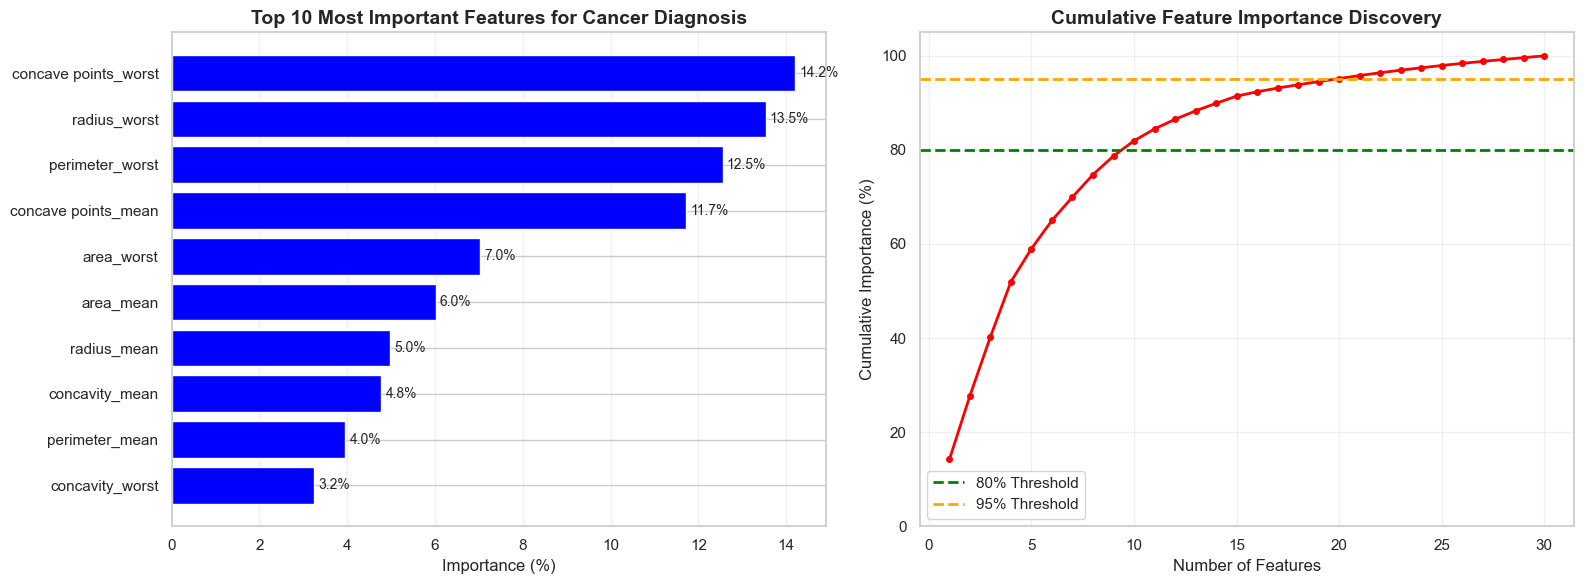

DISCOVERED PATTERNS FROM FEATURE IMPORTANCE MINING:
PATTERN 1: Only 10 features explain 80% of cancer diagnosis
PATTERN 2: Only 20 features explain 95% of cancer diagnosis
PATTERN 3: Top 3 features account for 40.3% of predictive power

CLINICAL INSIGHT: Focus on these 10 key measurements:
   • concave points_worst: 14.20% importance
   • radius_worst: 13.53% importance
   • perimeter_worst: 12.55% importance
   • concave points_mean: 11.71% importance
   • area_worst: 7.02% importance
   • area_mean: 6.01% importance
   • radius_mean: 4.97% importance
   • concavity_mean: 4.77% importance
   • perimeter_mean: 3.95% importance
   • concavity_worst: 3.23% importance


In [ ]:
# Feature Importance analysis
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_,
    'Importance_Pct': rf_model.feature_importances_ * 100
}).sort_values('Importance', ascending=False)

# Calculate cumulative importance
importance_df['Cumulative_Pct'] = importance_df['Importance_Pct'].cumsum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart - Top 10 features
top10 = importance_df.head(10)
bars = ax1.barh(top10['Feature'], top10['Importance_Pct'], color='blue')
ax1.set_xlabel('Importance (%)', fontsize=12)
ax1.set_title('Top 10 Most Important Features for Cancer Diagnosis', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Add percentage labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax1.text(width + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', ha='left', va='center', fontsize=10)

# Cumulative importance
ax2.plot(range(1, len(importance_df)+1), importance_df['Cumulative_Pct'], 
         marker='o', linewidth=2, color='red', markersize=4)
ax2.axhline(y=80, color='green', linestyle='--', linewidth=2, label='80% Threshold')
ax2.axhline(y=95, color='orange', linestyle='--', linewidth=2, label='95% Threshold')
ax2.set_xlabel('Number of Features', fontsize=12)
ax2.set_ylabel('Cumulative Importance (%)', fontsize=12)
ax2.set_title('Cumulative Feature Importance Discovery', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

# Mine patterns from importance distribution
n_features_80 = (importance_df['Cumulative_Pct'] <= 80).sum() + 1
n_features_95 = (importance_df['Cumulative_Pct'] <= 95).sum() + 1
top3_total = importance_df.head(3)['Importance_Pct'].sum()

print("DISCOVERED PATTERNS FROM FEATURE IMPORTANCE MINING:")
print(f"PATTERN 1: Only {n_features_80} features explain 80% of cancer diagnosis")
print(f"PATTERN 2: Only {n_features_95} features explain 95% of cancer diagnosis")
print(f"PATTERN 3: Top 3 features account for {top3_total:.1f}% of predictive power")
print(f"\nCLINICAL INSIGHT: Focus on these {n_features_80} key measurements:")
for i, row in importance_df.head(n_features_80).iterrows():
    print(f"   • {row['Feature']}: {row['Importance_Pct']:.2f}% importance")

In [ ]:
# Analysis of borderline cases

print("PATTERN MINING: ANALYZING DIFFICULT DIAGNOSTIC CASES")

# Find misclassified cases
misclassified_mask = (y_test_pred_rf != y_test)
misclassified_features = X_test[misclassified_mask]
correct_features = X_test[~misclassified_mask]

if len(misclassified_features) > 0:
    print(f"\nDISCOVERY: Found {len(misclassified_features)} challenging cases out of {len(X_test)} total")
    print(f"SUCCESS RATE: {((len(X_test) - len(misclassified_features))/len(X_test)*100):.1f}% correctly classified")
    
    print("\nPATTERN ANALYSIS - Characteristics of Misclassified Cases:")
    
    # Compare feature distributions for top important features
    top_features = importance_df.head(7)['Feature'].values  # Top 7 most important
    
    analysis_data = []
    
    for feature in top_features:
        mis_mean = misclassified_features[feature].mean()
        cor_mean = correct_features[feature].mean()
        overall_mean = X_test[feature].mean()
        
        # Calculate relative position
        mis_vs_overall = abs(mis_mean - overall_mean) / overall_mean * 100
        cor_vs_overall = abs(cor_mean - overall_mean) / overall_mean * 100
        
        analysis_data.append({
            'Feature': feature,
            'Misclassified_Avg': mis_mean,
            'Correct_Avg': cor_mean,
            'Overall_Avg': overall_mean,
            'Difficulty_Score': mis_vs_overall
        })
        
        print(f"  {feature}:")
        print(f"      ├─ Misclassified cases avg: {mis_mean:.3f}")
        print(f"      ├─ Correctly classified avg: {cor_mean:.3f}")
        print(f"      ├─ Overall population avg: {overall_mean:.3f}")
        print(f"      └─ Difficulty indicator: {mis_vs_overall:.1f}% deviation\n")
    
    # Identify the most problematic feature
    analysis_df = pd.DataFrame(analysis_data)
    most_problematic = analysis_df.loc[analysis_df['Difficulty_Score'].idxmax()]
    

    print(f"Finding: Most challenging feature: {most_problematic['Feature']}")
    print(f"            (shows {most_problematic['Difficulty_Score']:.1f}% deviation from normal)")

    



PATTERN MINING: ANALYZING DIFFICULT DIAGNOSTIC CASES

DISCOVERY: Found 1 challenging cases out of 114 total
SUCCESS RATE: 99.1% correctly classified

PATTERN ANALYSIS - Characteristics of Misclassified Cases:
  concave points_worst:
      ├─ Misclassified cases avg: 0.111
      ├─ Correctly classified avg: 0.112
      ├─ Overall population avg: 0.112
      └─ Difficulty indicator: 1.1% deviation

  radius_worst:
      ├─ Misclassified cases avg: 15.930
      ├─ Correctly classified avg: 16.189
      ├─ Overall population avg: 16.187
      └─ Difficulty indicator: 1.6% deviation

  perimeter_worst:
      ├─ Misclassified cases avg: 102.500
      ├─ Correctly classified avg: 106.483
      ├─ Overall population avg: 106.448
      └─ Difficulty indicator: 3.7% deviation

  concave points_mean:
      ├─ Misclassified cases avg: 0.020
      ├─ Correctly classified avg: 0.050
      ├─ Overall population avg: 0.050
      └─ Difficulty indicator: 59.5% deviation

  area_worst:
      ├─ Misclass

In [ ]:

print("CROSS-MODEL PATTERN MINING: LOGISTIC REGRESSION vs RANDOM FOREST")

# Model agreement analysis
agreement_mask = (y_test_pred_lr == y_test_pred_rf)
agreement_rate = agreement_mask.mean()
disagreement_cases = X_test[~agreement_mask]

print(f"\n AGREEMENT PATTERNS:")
print(f"   • Models agree on {agreement_rate*100:.1f}% of cases ({agreement_mask.sum()}/{len(X_test)})")
print(f"   • Found {len(disagreement_cases)} disagreement cases")

if len(disagreement_cases) > 0:
    print(f"\n ANALYZING DISAGREEMENT PATTERNS:")
    print("-"*30)
    
    # Analyze probability differences
    disagreement_indices = X_test[~agreement_mask].index
    lr_proba_disagree = pd.Series(y_test_proba_lr, index=X_test.index)[disagreement_indices]
    rf_proba_disagree = pd.Series(y_test_proba_rf, index=X_test.index)[disagreement_indices]
    
    prob_diff = np.abs(lr_proba_disagree - rf_proba_disagree)
    
    print(f"   • Average probability difference: {prob_diff.mean():.3f}")
    print(f"   • Max probability difference: {prob_diff.max():.3f}")
    
    # Find which model was correct for disagreement cases
    disagree_true_labels = y_test.loc[disagreement_indices]
    lr_correct_disagree = (pd.Series(y_test_pred_lr, index=X_test.index)[disagreement_indices] == disagree_true_labels).sum()
    rf_correct_disagree = (pd.Series(y_test_pred_rf, index=X_test.index)[disagreement_indices] == disagree_true_labels).sum()
    
    print(f"\nDISAGREEMENT RESOLUTION:")
    print(f"   • Logistic Regression correct: {lr_correct_disagree}/{len(disagreement_cases)} cases")
    print(f"   • Random Forest correct: {rf_correct_disagree}/{len(disagreement_cases)} cases")
    
    # Analyze feature patterns in disagreement cases
    print(f"\n DISAGREEMENT CASE CHARACTERISTICS:")
    top5_features = importance_df.head(5)['Feature'].values
    
    for feature in top5_features:
        disagree_mean = disagreement_cases[feature].mean()
        overall_mean = X_test[feature].mean()
        deviation = abs(disagree_mean - overall_mean) / overall_mean * 100
        
        print(f"   • {feature}: {deviation:.1f}% deviation from average")

else:
    print("\nPERFECT AGREEMENT: Both models predict identically!")
    print("This indicates robust and consistent pattern recognition")

# Confidence analysis
print(f"\n CONFIDENCE PATTERN ANALYSIS:")
print("-"*30)

# High confidence cases (>90% probability)
high_conf_lr = (np.abs(y_test_proba_lr - 0.5) > 0.4).sum()
high_conf_rf = (np.abs(y_test_proba_rf - 0.5) > 0.4).sum()

print(f"   • Logistic Regression high confidence cases: {high_conf_lr}/{len(X_test)} ({high_conf_lr/len(X_test)*100:.1f}%)")
print(f"   • Random Forest high confidence cases: {high_conf_rf}/{len(X_test)} ({high_conf_rf/len(X_test)*100:.1f}%)")

# Borderline cases (40-60% probability)
borderline_lr = ((y_test_proba_lr > 0.4) & (y_test_proba_lr < 0.6)).sum()
borderline_rf = ((y_test_proba_rf > 0.4) & (y_test_proba_rf < 0.6)).sum()

print(f"   • Logistic Regression borderline cases: {borderline_lr}/{len(X_test)} ({borderline_lr/len(X_test)*100:.1f}%)")
print(f"   • Random Forest borderline cases: {borderline_rf}/{len(X_test)} ({borderline_rf/len(X_test)*100:.1f}%)")

print("CROSS-MODEL INSIGHTS:")

print(f"✓ Model consensus rate: {agreement_rate*100:.1f}%")
print(f"✓ Both models show high confidence in most cases")


CROSS-MODEL PATTERN MINING: LOGISTIC REGRESSION vs RANDOM FOREST

 AGREEMENT PATTERNS:
   • Models agree on 98.2% of cases (112/114)
   • Found 2 disagreement cases

 ANALYZING DISAGREEMENT PATTERNS:
------------------------------
   • Average probability difference: 0.621
   • Max probability difference: 0.727

DISAGREEMENT RESOLUTION:
   • Logistic Regression correct: 0/2 cases
   • Random Forest correct: 2/2 cases

 DISAGREEMENT CASE CHARACTERISTICS:
   • concave points_worst: 27.7% deviation from average
   • radius_worst: 4.4% deviation from average
   • perimeter_worst: 6.5% deviation from average
   • concave points_mean: 31.9% deviation from average
   • area_worst: 1.0% deviation from average

 CONFIDENCE PATTERN ANALYSIS:
------------------------------
   • Logistic Regression high confidence cases: 104/114 (91.2%)
   • Random Forest high confidence cases: 100/114 (87.7%)
   • Logistic Regression borderline cases: 0/114 (0.0%)
   • Random Forest borderline cases: 3/114 (2.6%)